In [160]:
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import tarfile
import seaborn as sns
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix


In [3]:
max_samples = 100000
INPUT_DATA_PATH = "data/all_attack_benign_samples.tar.xz" 
ATTACK_PATH = "data/all_attack_benign_samples/attack_data/attack_samples_1sec.csv.tar.xz"
BENIGN_PATH = "data/all_attack_benign_samples/benign_data/benign_samples_1sec.csv.tar.xz"

In [5]:
def read_tar_xz_csv(path, max_samples=None):
    rows = []
    total = 0
    with tarfile.open(path, mode="r:xz") as tar:
        members = [m for m in tar.getmembers() if m.name.endswith(".csv")]
        
        csv_member = members[0]
        f = tar.extractfile(csv_member)
        
        for chunk in pd.read_csv(f, chunksize=50000):
            rows.append(chunk)
            total += len(chunk)
            if max_samples and total >= max_samples:
                break

    df = pd.concat(rows)
    return df.iloc[:max_samples]

In [10]:
attack_pd = read_tar_xz_csv(ATTACK_PATH, None)
benign_pd = read_tar_xz_csv(BENIGN_PATH, None)

In [ ]:
print(attack_pd.shape)
print(benign_pd.shape)

(90391, 94)
(136800, 94)


In [16]:
benign_pd.head()

,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:40.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:40.400000Z,2025-09-09T14:09:41.400000Z,...,0.0,0.006059,62.800000,64.0,61.0,1.469694,1870.500000,3081.0,660.0,1210.500000
1,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:41.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:41.400000Z,2025-09-09T14:09:42.400000Z,...,0.0,0.016469,62.500000,64.0,61.0,1.500000,1870.500000,3081.0,660.0,1210.500000
2,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:42.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:42.400000Z,2025-09-09T14:09:43.400000Z,...,0.0,0.034312,61.571429,64.0,53.0,3.736199,2441.285714,4736.0,135.0,1813.237335
3,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:43.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:43.400000Z,2025-09-09T14:09:44.400000Z,...,0.0,0.012790,62.500000,64.0,61.0,1.500000,1870.500000,3081.0,660.0,1210.500000
4,router,28:87:ba:bd:c6:6c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:09:44.400000Z_2025-09-09T14:09:4...,2025-09-09T14:09:44.400000Z,2025-09-09T14:09:45.400000Z,...,0.0,0.017764,62.800000,64.0,61.0,1.469694,2112.600000,3081.0,660.0,1186.042933


In [18]:
attack_pd.head()

,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:10.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:10.709000Z,2025-01-23T15:31:11.709000Z,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:11.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:11.709000Z,2025-01-23T15:31:12.709000Z,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:12.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:12.709000Z,2025-01-23T15:31:13.709000Z,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:13.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:13.709000Z,2025-01-23T15:31:14.709000Z,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:14.709000Z_2025-01-23T15:31:1...,2025-01-23T15:31:14.709000Z,2025-01-23T15:31:15.709000Z,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 1.  Data Cleaning

In [164]:
comb_df = pd.concat([attack_pd, benign_pd])
comb_df['timestamp_start'] = pd.to_datetime(comb_df['timestamp_start'])
print(comb_df.columns)

#remove ['label1', label3, label4] : only concerned with main classification
# device identifiers: based on specific set up
remove_cols = ['label1', 'label3', 'label4', 'device_name', 'device_mac', 'label_full']
comb_df.drop(remove_cols, axis=1, inplace=True)

Index(['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3',
       'label4', 'timestamp', 'timestamp_start', 'timestamp_end',
       'log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min',
       'log_data-ranges_std_deviation', 'log_data-types',
       'log_data-types_count', 'log_interval-messages', 'log_messages_count',
       'network_fragmentation-score', 'network_fragmented-packets',
       'network_header-length_avg', 'network_header-length_max',
       'network_header-length_min', 'network_header-length_std_deviation',
       'network_interval-packets', 'network_ip-flags_avg',
       'network_ip-flags_max', 'network_ip-flags_min',
       'network_ip-flags_std_deviation', 'network_ip-length_avg',
       'network_ip-length_max', 'network_ip-length_min',
       'network_ip-length_std_deviation', 'network_ips_all',
       'network_ips_all_count', 'network_ips_dst', 'network_ips_dst_count',
       'network_ips_src', 'network_ips_src_count', 'network_

In [134]:
# check data quality - NaNs per column
comb_na = comb_df.isna().sum()
comb_na = comb_na[comb_na != 0]
print(comb_na)

Series([], dtype: int64)


#### 1.A : Manual feature reducton
Based on statistics such as correlation, variance, etc

In [157]:
# check correlation and find redundant columns
num_cols = comb_df.select_dtypes(include='number')
print(num_cols.shape)
corr = num_cols.corr()

#upper triangle of corr
corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_threshold = 0.95
high_corr = [(col1, col2, corr.loc[col1,col2])
             for col1 in corr.columns
             for col2 in corr.columns
             if corr.loc[col1, col2] > corr_threshold]
high_corr = np.array(high_corr, dtype=object)
sorted_high_corr = high_corr[np.argsort(high_corr[:, 2].astype(float))[::-1]]
for c1, c2, val in sorted_high_corr:
    print(f"{c1} - {c2}: {val:.2f}")

# print("********************\n")

# col_pairs = [c1 for c1,c2,val in sorted_high_corr] + [c2 for c1,c2,val in sorted_high_corr]
# col_counts = Counter(col_pairs)
# col_counts_sorted = dict(sorted(col_counts.items(), key=lambda x:x[1], reverse=True))
# for col, count in col_counts_sorted.items():
#     print(f"{col}: {count} pairs")

(227191, 71)
network_macs_dst_count - network_macs_src_count: 1.00
network_header-length_avg - network_header-length_min: 1.00
network_header-length_avg - network_header-length_max: 1.00
network_header-length_max - network_header-length_min: 1.00
network_ip-length_max - network_packet-size_max: 1.00
network_ips_all_count - network_ips_dst_count: 1.00
network_mss_avg - network_mss_max: 1.00
log_data-ranges_avg - log_data-ranges_max: 1.00
network_mss_avg - network_mss_min: 1.00
network_ip-length_max - network_payload-length_max: 1.00
network_packet-size_max - network_payload-length_max: 1.00
network_fragmentation-score - network_fragmented-packets: 1.00
network_mss_max - network_mss_min: 1.00
network_ips_src_count - network_macs_dst_count: 0.99
network_ips_src_count - network_macs_src_count: 0.99
network_packets_all_count - network_packets_dst_count: 0.99
network_macs_all_count - network_macs_dst_count: 0.99
network_macs_all_count - network_macs_src_count: 0.99
network_tcp-flags-fin_coun

In [159]:
remove_cols = set()
keep_cols = set()

# discard high corr columns (redundant)
for c1, c2, _ in sorted_high_corr:
    if c1 not in keep_cols and c2 not in keep_cols:
        #prioritize avg or count
        if "_avg" in c1 or "_count" in c1:
            keep_cols.add(c1)
            remove_cols.add(c2)
        elif "_avg" in c2 or "_count" in c2:
            keep_cols.add(c2)
            remove_cols.add(c1)
        else:
            keep_cols.add(c1)
            remove_cols.add(c2)
    elif c1 in keep_cols:
        remove_cols.add(c2)
    elif c2 in keep_cols:
        remove_cols.add(c1)

print(f"Keeping cols with high corr: {keep_cols}")
print(f"Dropping cols with high corr: {remove_cols}")

# discard low_variance columns
variance = num_cols.var()
var_threshold = 1e-3
low_var = variance[variance < var_threshold]
low_var_cols = low_var.index.tolist()
print(f"dropping low var cols: {low_var_cols}")
remove_cols.update(low_var_cols)

high_corr_cols = []
reduced_manual = comb_df.drop(remove_cols, axis=1)
print(f"Final shape: {reduced_manual.shape}")



Keeping cols with high corr: {'network_mss_max', 'network_header-length_avg', 'network_header-length_max', 'log_data-ranges_max', 'network_macs_dst_count', 'network_ip-length_avg', 'network_ip-length_std_deviation', 'network_packets_all_count', 'network_ips_all_count', 'network_packet-size_max', 'network_tcp-flags-ack_count', 'network_mss_avg', 'log_data-ranges_avg', 'network_ips_src_count', 'network_ip-length_min', 'network_ports_all_count', 'network_ip-length_max', 'network_packet-size_avg', 'network_macs_all_count', 'network_tcp-flags-fin_count', 'network_fragmentation-score'}
Dropping cols with high corr: {'network_mss_max', 'network_header-length_max', 'log_data-ranges_max', 'network_packets_dst_count', 'network_header-length_min', 'network_ports_src_count', 'network_payload-length_avg', 'network_packet-size_max', 'network_tcp-flags-psh_count', 'network_ips_dst_count', 'log_data-ranges_min', 'network_payload-length_max', 'network_ips_src_count', 'network_payload-length_min', 'netw

### 1b: PCA reduction

In [175]:

time_cols = ['timestamp', 'timestamp_start', 'timestamp_end']
time_data = comb_df[time_cols]
y = comb_df['label2']
x = comb_df.drop(['label2'] + time_cols, axis=1)
print(x.columns)
# standardize data
scaler = StandardScaler()
scaled_comb = scaler.fit_transform(x)

pca = PCA(n_components = 30)
comb_pca = pca.fit_transform(scaled_comb)
print(f"Post PCA size: {comb_pca.shape}")



Index(['log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min',
       'log_data-ranges_std_deviation', 'log_data-types',
       'log_data-types_count', 'log_interval-messages', 'log_messages_count',
       'network_fragmentation-score', 'network_fragmented-packets',
       'network_header-length_avg', 'network_header-length_max',
       'network_header-length_min', 'network_header-length_std_deviation',
       'network_interval-packets', 'network_ip-flags_avg',
       'network_ip-flags_max', 'network_ip-flags_min',
       'network_ip-flags_std_deviation', 'network_ip-length_avg',
       'network_ip-length_max', 'network_ip-length_min',
       'network_ip-length_std_deviation', 'network_ips_all',
       'network_ips_all_count', 'network_ips_dst', 'network_ips_dst_count',
       'network_ips_src', 'network_ips_src_count', 'network_macs_all',
       'network_macs_all_count', 'network_macs_dst', 'network_macs_dst_count',
       'network_macs_src', 'network_macs_src_count', 'ne

ValueError: could not convert string to float: '[]'

### Data distribution
- On raw data, not reduced data

In [108]:
start_time = comb_df['timestamp_start'].min()
end_time = comb_df['timestamp_start'].max()
print(f'Start_time: {start_time}, end time = {end_time}')

Start_time: 2025-01-15 13:04:54.353000+00:00, end time = 2025-09-09 15:09:39.400000+00:00


['ddos' 'dos' 'mitm' 'web' 'recon' 'malware' 'bruteforce']


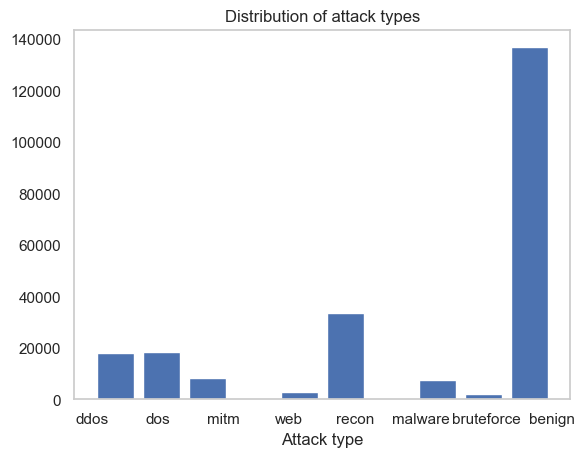

In [109]:
print(attack_pd['label2'].unique())
comb_df['label2'].hist(grid=False, rwidth=0.8)
plt.title('Distribution of attack types')
plt.xlabel('Attack type')
plt.show()

### Time series Analysis

C:\Users\kelly\AppData\Local\Temp\ipykernel_99580\177297281.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  counts = month_df.groupby([pd.Grouper(freq='1M'), 'label2']).size().unstack(fill_value=0)


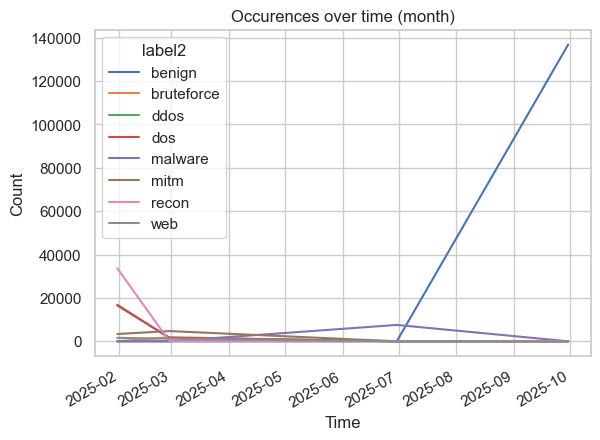

In [110]:
month_df = comb_df.set_index('timestamp_start')
month_df = month_df.sort_index()

counts = month_df.groupby([pd.Grouper(freq='1M'), 'label2']).size().unstack(fill_value=0)
ax = counts.plot(kind='line', title='Occurences over time (month)')
ax.set_xlabel('Time')
ax.set_ylabel('Count')
plt.gcf().autofmt_xdate()
plt.show()

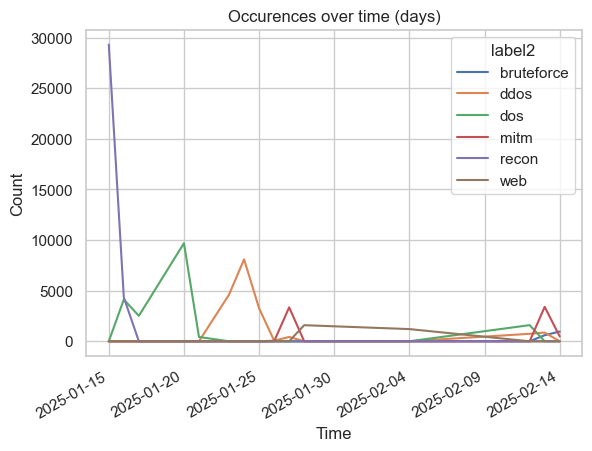

In [111]:
### smaller time window
day_df = comb_df.set_index('timestamp_start')
day_df = day_df.sort_index()

start_time = day_df.index.min()
end_time =  start_time + pd.Timedelta(days=30)
month_comb = day_df.loc[start_time:end_time]
counts_month = month_comb.groupby([pd.Grouper(freq='1D'), 'label2']).size().unstack(fill_value=0)
ax = counts_month.plot(kind='line', title='Occurences over time (days)')
ax.set_xlabel('Time')
ax.set_ylabel('Count')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5) )
plt.gcf().autofmt_xdate()
plt.show()

In [56]:
# groupings
packet_counts = ['network_packets_all_count', "network_packets_src_count", 'network_packets_dst_count']
ip_counts = ['network_ips_all_count', 'network_ips_src_count', 'network_ips_dst_count']
tcp_counts = ['network_tcp-flags-syn_count', 'network_tcp-flags-rst_count', 'network_tcp-flags-fin_count']

In [120]:
# plots quantitative data over time at sampling rate
# columns: list of column labels to plot over
# sampling rate: time units to sample over
# start_time: optional
# end_time: optional
def plot_time(columns, sampling_rate, start_time=None, end_time=None, title=None):
    plot_df = comb_df.set_index('timestamp_start')
    plot_df = plot_df.sort_index()
    plot_df = plot_df[columns]
    plot_df = plot_df.sort_index()
    plot_df = plot_df.resample(sampling_rate).sum().reset_index()
    plot_melt = plot_df.melt(id_vars='timestamp_start', 
                                    value_vars=columns, var_name="metric",
                                    value_name='count')
    sns.set_theme(style="whitegrid")
    ax = sns.lineplot(data=plot_melt, x="timestamp_start", y='count', hue='metric')
    ax.tick_params(axis='x', labelrotation=45)
    if start_time and end_time:
        ax.set_xlim(start_time, end_time)
    ax.set(title=title)
    plt.show()


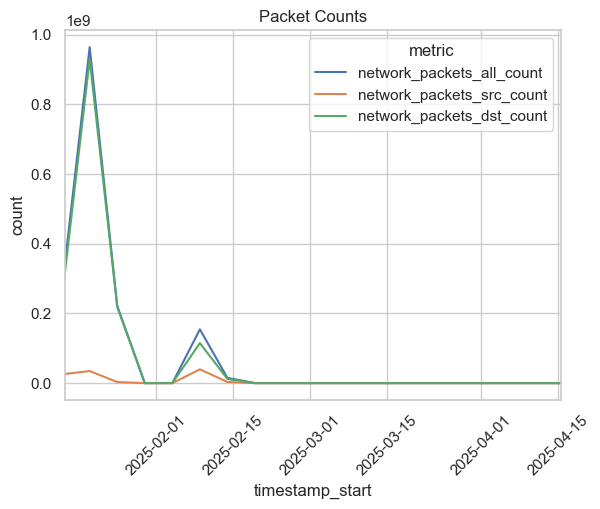

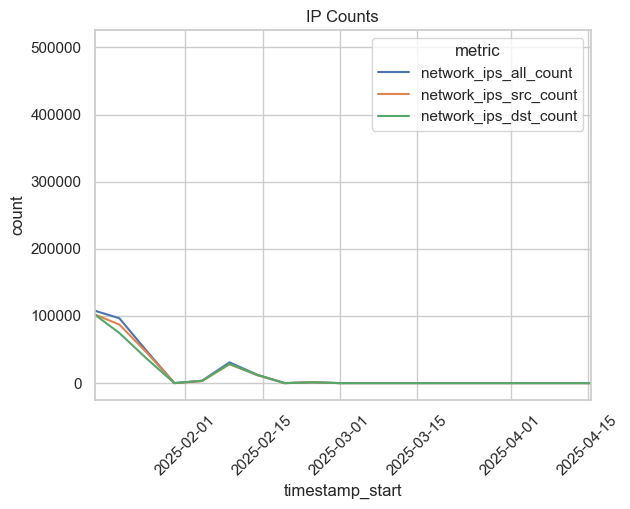

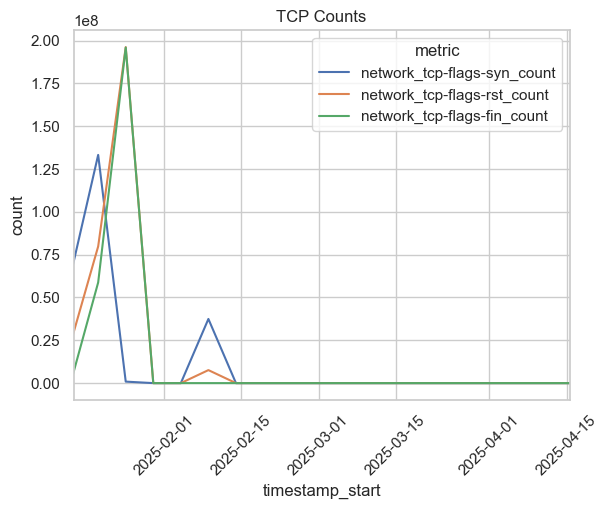

In [ ]:
packet = comb_df.set_index('timestamp_start')
packet = packet.sort_index()
start_time = packet.index.min()
end_time =  start_time + pd.Timedelta(days=90)
plot_time(packet_counts, "5D", start_time, end_time, title="Packet Counts")
plot_time(ip_counts, "5D", start_time, end_time, title="IP Counts")
plot_time(tcp_counts, "5D", start_time, end_time, title="TCP Counts")